In [2]:
import torch
import numpy as np
import torch.nn as nn
from sklearn.datasets import fetch_openml
from matplotlib import pyplot as plt

from torch.utils.data import DataLoader, Dataset

In [3]:
LR = 0.001
batch_size = 1024
num_epochs = 30

In [4]:
# 從 sklearn 載入 MNIST 資料集
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X = mnist.data.to_numpy()  # shape: (70000, 784)
y = mnist.target.astype(np.uint8).to_numpy()  # shape: (70000,)

# 分割訓練集和測試集（前60000為訓練集，後10000為測試集）
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

# 正規化到 [0, 1] 範圍
X_train = X_train / 255.0
X_test = X_test / 255.0

In [5]:
# 建立自定義 Dataset 類別
class MNISTDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.FloatTensor(data)
        self.labels = torch.LongTensor(labels)
    
    def __getitem__(self, index):
        return self.data[index], self.labels[index]
    
    def __len__(self):
        return len(self.data)

# 建立訓練和測試資料集
trainset = MNISTDataset(X_train, y_train)
testset = MNISTDataset(X_test, y_test)

train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=True)

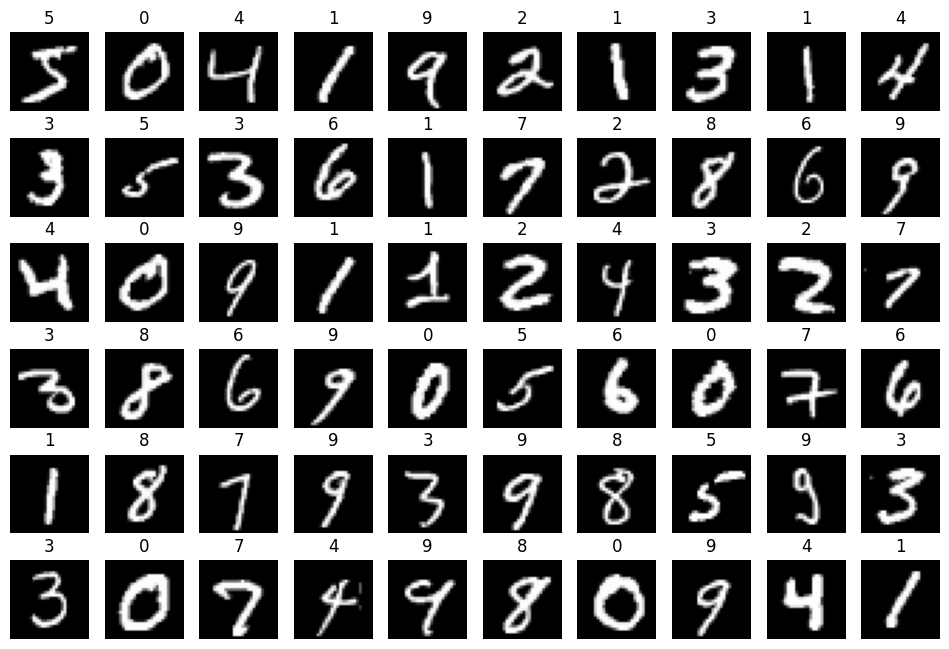

In [6]:
figure = plt.figure(figsize=(12, 8))
rows, cols = 6, 10
for i in range(1, rows * cols + 1):
    # 按数据集的顺序选前几个数据
    img, label = X_train[i - 1].reshape(28, 28), y_train[i - 1]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis('off')
    plt.imshow(img, cmap='gray')

In [7]:
input_size = 784
hidden_sizes = [128, 64]
output_size = 10

loss_func = nn.CrossEntropyLoss()   # the target label is not one-hotted

model_1 = nn.Sequential(nn.Linear(input_size, hidden_sizes[0]),
                        nn.ReLU(),
                        nn.Linear(hidden_sizes[0], hidden_sizes[1]),
                        nn.ReLU(),
                        nn.Linear(hidden_sizes[1], output_size))
optimizer = torch.optim.AdamW(model_1.parameters(), lr=LR, weight_decay=0.1)   # optimize all cnn parameters

In [8]:
training_loss = []
training_accuracy = []
validation_loss = []
validation_accuracy = []

In [9]:
%%time
# Traning the Model
#history-like list for store loss & acc value
for epoch in range(num_epochs):
    #training model & store loss & acc / epoch
    correct_train = 0
    total_train = 0
    for i, (images, labels) in enumerate(train_loader):
        # 1.Define variables
        train = images
        labels = labels
        # 2.Clear gradients
        optimizer.zero_grad()
        # 3.Forward propagation
        outputs = model_1(train)
        # 4.Calculate softmax and cross entropy loss
        train_loss = loss_func(outputs, labels)
        # 5.Calculate gradients
        train_loss.backward()
        # 6.Update parameters
        optimizer.step()
        # 7.Get predictions from the maximum value
        predicted = torch.max(outputs.data, 1)[1]
        # 8.Total number of labels
        total_train += len(labels)
        # 9.Total correct predictions
        correct_train += (predicted == labels).float().sum()
    #10.store val_acc / epoch
    train_accuracy = 100 * correct_train / float(total_train)
    training_accuracy.append(train_accuracy)
    # 11.store loss / epoch
    training_loss.append(train_loss.data)

    #evaluate model & store loss & acc / epoch
    correct_test = 0
    total_test = 0
    for images, labels in test_loader:
        # 1.Define variables
        test = images
        # 2.Forward propagation
        outputs = model_1(test)
        # 3.Calculate softmax and cross entropy loss
        val_loss = loss_func(outputs, labels)
        # 4.Get predictions from the maximum value
        predicted = torch.max(outputs.data, 1)[1]
        # 5.Total number of labels
        total_test += len(labels)
        # 6.Total correct predictions
        correct_test += (predicted == labels).float().sum()
    #6.store val_acc / epoch
    val_accuracy = 100 * correct_test / float(total_test)
    validation_accuracy.append(val_accuracy)
    # 11.store val_loss / epoch
    validation_loss.append(val_loss.data)
    print('Train Epoch: {}/{} Traing_Loss: {} Traing_acc: {:.6f}% Val_Loss: {} Val_accuracy: {:.6f}%'
        .format(epoch+1, num_epochs, train_loss.data, train_accuracy, val_loss.data, val_accuracy))

Train Epoch: 1/30 Traing_Loss: 0.43486762046813965 Traing_acc: 73.443336% Val_Loss: 0.3503316640853882 Val_accuracy: 88.970001%
Train Epoch: 2/30 Traing_Loss: 0.2857404947280884 Traing_acc: 90.543335% Val_Loss: 0.28042182326316833 Val_accuracy: 92.099998%
Train Epoch: 2/30 Traing_Loss: 0.2857404947280884 Traing_acc: 90.543335% Val_Loss: 0.28042182326316833 Val_accuracy: 92.099998%
Train Epoch: 3/30 Traing_Loss: 0.25651291012763977 Traing_acc: 92.471664% Val_Loss: 0.2855716645717621 Val_accuracy: 93.309998%
Train Epoch: 3/30 Traing_Loss: 0.25651291012763977 Traing_acc: 92.471664% Val_Loss: 0.2855716645717621 Val_accuracy: 93.309998%
Train Epoch: 4/30 Traing_Loss: 0.19451464712619781 Traing_acc: 93.586670% Val_Loss: 0.20849178731441498 Val_accuracy: 93.660004%
Train Epoch: 4/30 Traing_Loss: 0.19451464712619781 Traing_acc: 93.586670% Val_Loss: 0.20849178731441498 Val_accuracy: 93.660004%
Train Epoch: 5/30 Traing_Loss: 0.19178076088428497 Traing_acc: 94.348335% Val_Loss: 0.1815119534730911

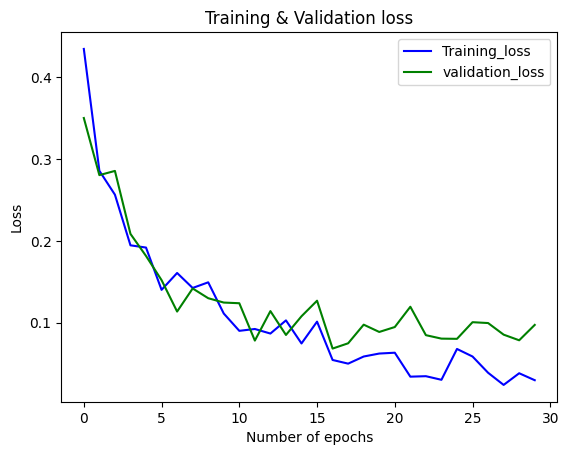

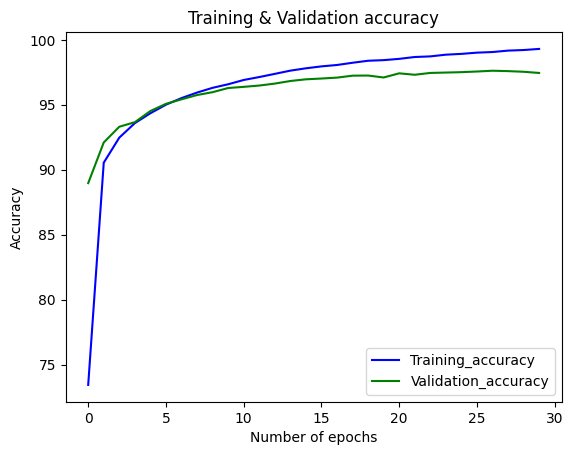

In [10]:
# visualization
plt.plot(range(num_epochs), training_loss, 'b-', label='Training_loss')
plt.plot(range(num_epochs), validation_loss, 'g-', label='validation_loss')
plt.title('Training & Validation loss')
plt.xlabel('Number of epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
plt.plot(range(num_epochs), training_accuracy, 'b-', label='Training_accuracy')
plt.plot(range(num_epochs), validation_accuracy, 'g-', label='Validation_accuracy')
plt.title('Training & Validation accuracy')
plt.xlabel('Number of epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

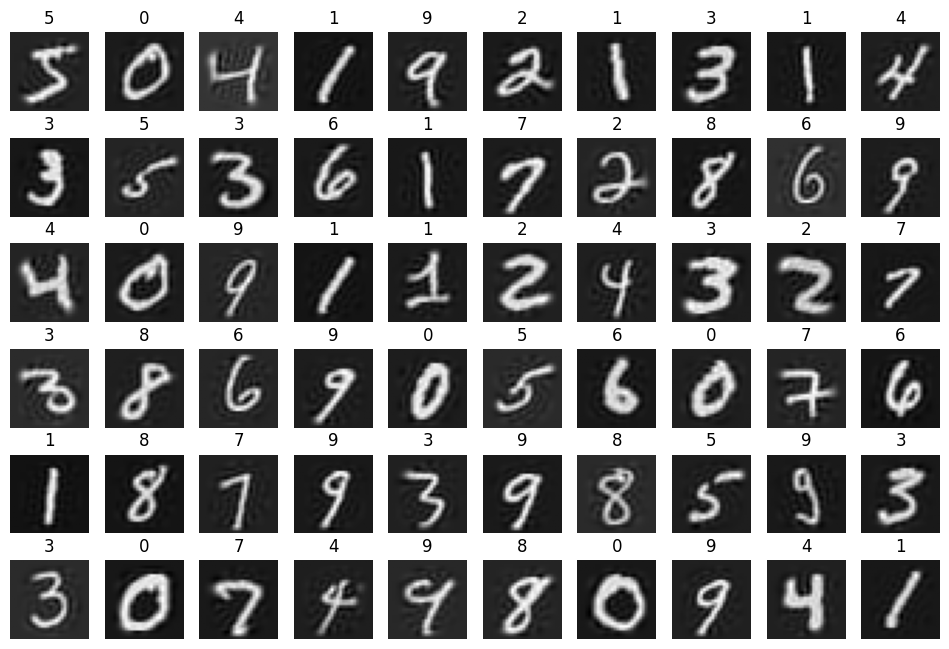

In [11]:
from sklearn.decomposition import PCA
pca = PCA(n_components=154) 
#pca = PCA(n_components=0.95) # 保留95%的方差，结果也是154个特征
X_reduced = pca.fit_transform(X_train)	# 压缩
# X_reduced.shape = (60000, 154)
X_recovered = pca.inverse_transform(X_reduced).reshape(60000, 28, 28)

figure = plt.figure(figsize=(12, 8))
rows, cols = 6, 10
for i in range(1, rows * cols + 1):
    # 按数据集的顺序选前几个数据
    img, label = X_recovered[i - 1], y_train[i - 1]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis('off')
    plt.imshow(img, cmap='gray')

In [12]:
# 建立 PCA 降維後的資料集
pca_train_dataset = MNISTDataset(X_reduced, y_train)
pca_test_dataset = MNISTDataset(pca.transform(X_test), y_test)
pca_train_loader = DataLoader(pca_train_dataset, batch_size=batch_size, shuffle=True)
pca_test_loader = DataLoader(pca_test_dataset, batch_size=batch_size, shuffle=True)

In [13]:
input_size = X_reduced.shape[1]
hidden_sizes = [128, 64]
output_size = 10

loss_func = nn.CrossEntropyLoss()   # the target label is not one-hotted

model_2 = nn.Sequential(nn.Linear(input_size, hidden_sizes[0]),
                        nn.ReLU(),
                        nn.Linear(hidden_sizes[0], hidden_sizes[1]),
                        nn.ReLU(),
                        nn.Linear(hidden_sizes[1], output_size))
optimizer = torch.optim.AdamW(model_2.parameters(), lr=LR, weight_decay=1)   # optimize all cnn parameters

In [14]:
training_loss = []
training_accuracy = []
validation_loss = []
validation_accuracy = []

In [15]:
%%time
# Traning the Model
#history-like list for store loss & acc value
for epoch in range(num_epochs):
    #training model & store loss & acc / epoch
    correct_train = 0
    total_train = 0
    for i, (images, labels) in enumerate(pca_train_loader):
        # 1.Define variables
        train = images
        labels = labels
        # 2.Clear gradients
        optimizer.zero_grad()
        # 3.Forward propagation
        outputs = model_2(train)
        # 4.Calculate softmax and cross entropy loss
        train_loss = loss_func(outputs, labels)
        # 5.Calculate gradients
        train_loss.backward()
        # 6.Update parameters
        optimizer.step()
        # 7.Get predictions from the maximum value
        predicted = torch.max(outputs.data, 1)[1]
        # 8.Total number of labels
        total_train += len(labels)
        # 9.Total correct predictions
        correct_train += (predicted == labels).float().sum()
    #10.store val_acc / epoch
    train_accuracy = 100 * correct_train / float(total_train)
    training_accuracy.append(train_accuracy)
    # 11.store loss / epoch
    training_loss.append(train_loss.data)

    #evaluate model & store loss & acc / epoch
    correct_test = 0
    total_test = 0
    for images, labels in pca_test_loader:
        # 1.Define variables
        test = images
        # 2.Forward propagation
        outputs = model_2(test)
        # 3.Calculate softmax and cross entropy loss
        val_loss = loss_func(outputs, labels)
        # 4.Get predictions from the maximum value
        predicted = torch.max(outputs.data, 1)[1]
        # 5.Total number of labels
        total_test += len(labels)
        # 6.Total correct predictions
        correct_test += (predicted == labels).float().sum()
    #6.store val_acc / epoch
    val_accuracy = 100 * correct_test / float(total_test)
    validation_accuracy.append(val_accuracy)
    # 11.store val_loss / epoch
    validation_loss.append(val_loss.data)
    print('Train Epoch: {}/{} Traing_Loss: {} Traing_acc: {:.6f}% Val_Loss: {} Val_accuracy: {:.6f}%'
        .format(epoch+1, num_epochs, train_loss.data, train_accuracy, val_loss.data, val_accuracy))

Train Epoch: 1/30 Traing_Loss: 0.6349428296089172 Traing_acc: 64.828331% Val_Loss: 0.6575562357902527 Val_accuracy: 87.820000%
Train Epoch: 2/30 Traing_Loss: 0.31522563099861145 Traing_acc: 90.511665% Val_Loss: 0.28872475028038025 Val_accuracy: 92.739998%
Train Epoch: 3/30 Traing_Loss: 0.2340695708990097 Traing_acc: 93.379997% Val_Loss: 0.21714997291564941 Val_accuracy: 93.930000%
Train Epoch: 2/30 Traing_Loss: 0.31522563099861145 Traing_acc: 90.511665% Val_Loss: 0.28872475028038025 Val_accuracy: 92.739998%
Train Epoch: 3/30 Traing_Loss: 0.2340695708990097 Traing_acc: 93.379997% Val_Loss: 0.21714997291564941 Val_accuracy: 93.930000%
Train Epoch: 4/30 Traing_Loss: 0.18231162428855896 Traing_acc: 94.513336% Val_Loss: 0.17457160353660583 Val_accuracy: 94.779999%
Train Epoch: 4/30 Traing_Loss: 0.18231162428855896 Traing_acc: 94.513336% Val_Loss: 0.17457160353660583 Val_accuracy: 94.779999%
Train Epoch: 5/30 Traing_Loss: 0.15293338894844055 Traing_acc: 95.375000% Val_Loss: 0.152430847287178

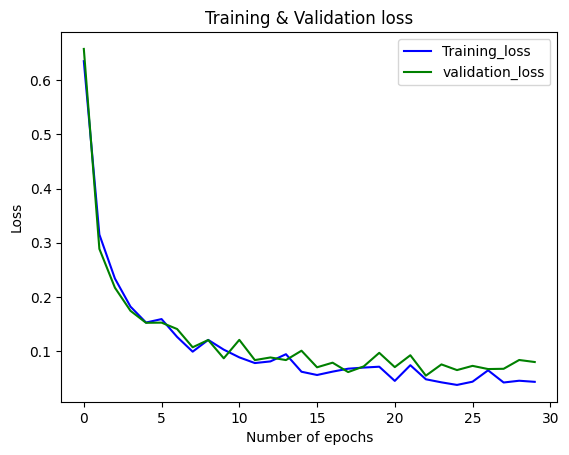

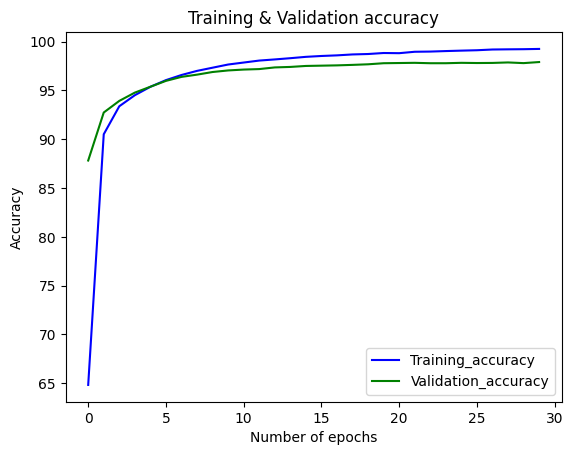

In [16]:
# visualization
plt.plot(range(num_epochs), training_loss, 'b-', label='Training_loss')
plt.plot(range(num_epochs), validation_loss, 'g-', label='validation_loss')
plt.title('Training & Validation loss')
plt.xlabel('Number of epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
plt.plot(range(num_epochs), training_accuracy, 'b-', label='Training_accuracy')
plt.plot(range(num_epochs), validation_accuracy, 'g-', label='Validation_accuracy')
plt.title('Training & Validation accuracy')
plt.xlabel('Number of epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [17]:
pca = PCA(n_components=200) 
X_reduced = pca.fit_transform(trainset.data.numpy().reshape(60000, 28*28))
# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
total_explained_variance_ratio = explained_variance_ratio.sum()

# Print results
print(f"\nExplained Variance Ratio:\n{explained_variance_ratio}")
print(f"Total Explained Variance Ratio: {total_explained_variance_ratio:.4f}")


Explained Variance Ratio:
[0.09704597 0.07095881 0.06169057 0.05389371 0.04868746 0.04312202
 0.03271902 0.02883871 0.02762014 0.0235699  0.02109177 0.02022984
 0.01715812 0.016921   0.01578629 0.01482944 0.01324559 0.01276891
 0.01187259 0.0115268  0.0106616  0.01006709 0.00953569 0.0091254
 0.00883403 0.00839313 0.00812573 0.00786361 0.00744729 0.00690854
 0.00658089 0.00648144 0.0060261  0.00586578 0.0057002  0.00543628
 0.00505787 0.00487855 0.00481427 0.00472265 0.00456746 0.00444833
 0.00418499 0.00398215 0.00384971 0.00375101 0.00362006 0.0035159
 0.00340058 0.00321874 0.00319015 0.00312804 0.0029598  0.00288956
 0.00284129 0.00271432 0.00269522 0.00258474 0.0025377  0.00244781
 0.00240504 0.0023927  0.00230409 0.00221534 0.00213719 0.0020723
 0.00203041 0.00196782 0.00192852 0.00188633 0.00186977 0.00181082
 0.00177561 0.00174898 0.00165757 0.00163895 0.0016146  0.00155115
 0.00147615 0.00143174 0.00142098 0.00141153 0.00140173 0.00135739
 0.00133849 0.00132397 0.00130158 0.00

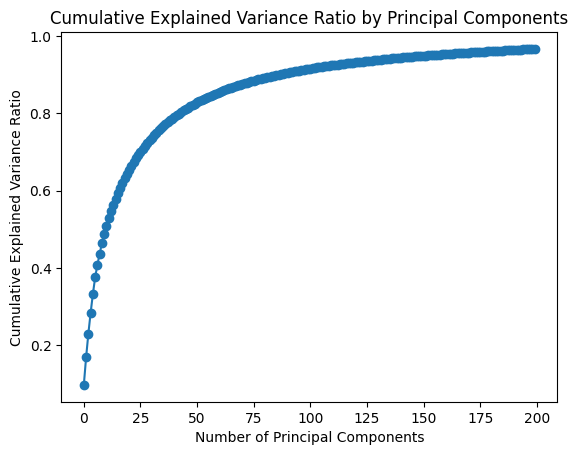

In [18]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# Plot explained variance ratio
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
plt.plot(cumulative_variance_ratio, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance Ratio by Principal Components')
plt.show()